In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
import sys
import os

# Thêm đường dẫn để Notebook tìm thấy thư mục 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data.cleaner import HotelCleaner

# 1. Khởi tạo đối tượng cleaner với dữ liệu df ban đầu
cleaner = HotelCleaner(df)

# 2. Gọi hàm clean_data để làm sạch
df_cleaned = cleaner.clean_data()

# 3. Kiểm tra xem còn giá trị null nào không
print("Số giá trị trống còn lại:", df_cleaned.isnull().sum().sum())
print("Danh sách các cột hiện có:", df_cleaned.columns.tolist())

Số giá trị trống còn lại: 0
Danh sách các cột hiện có: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


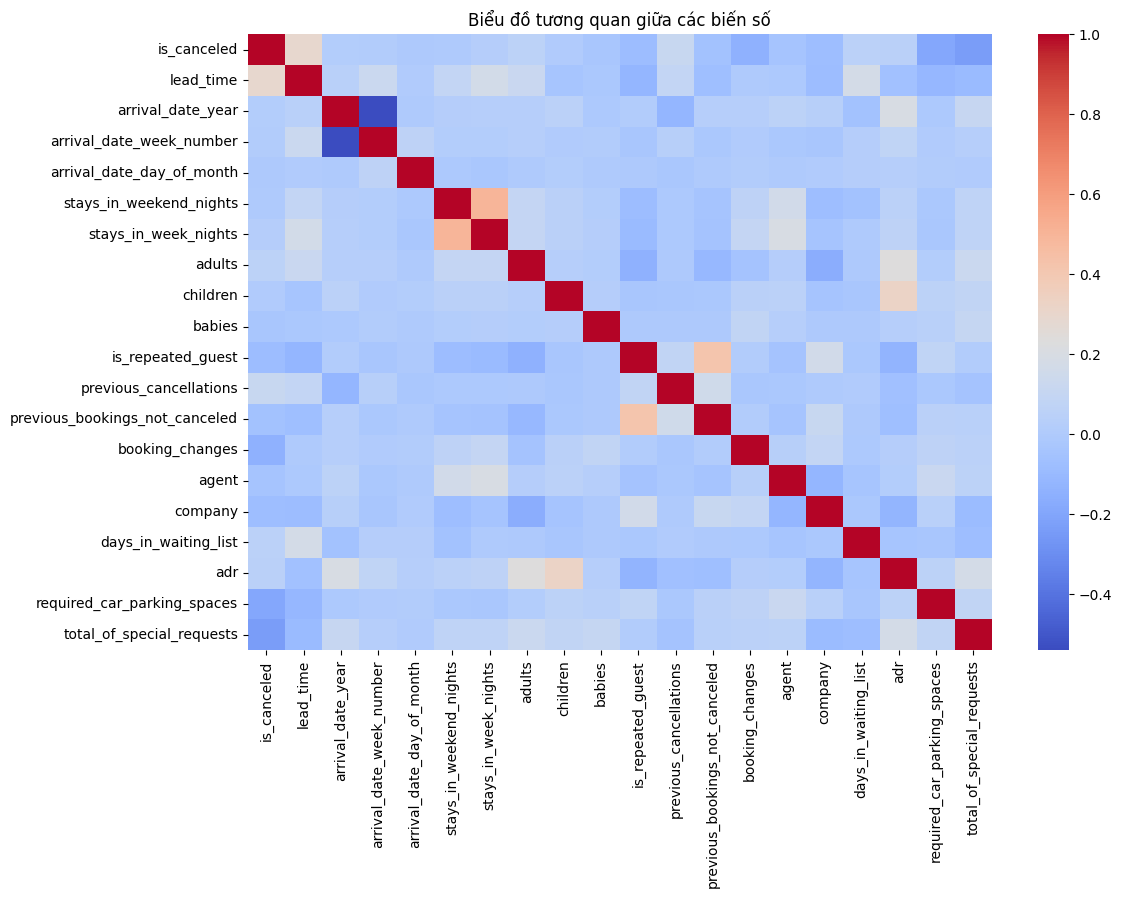

is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
children                          0.005036
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
babies                           -0.032491
agent                            -0.046529
previous_bookings_not_canceled   -0.057358
company                          -0.082995
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chọn các cột số để tính tương quan
numeric_df = df_cleaned.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()

# Vẽ biểu đồ Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Biểu đồ tương quan giữa các biến số')
plt.show()

# In ra các biến tương quan nhất với 'is_canceled'
print(corr['is_canceled'].sort_values(ascending=False))

In [9]:
from src.mining.association import run_apriori

# Gọi hàm với dữ liệu đã làm sạch
rules_df = run_apriori(df_cleaned)

# Hiển thị kết quả
print("TOP 5 NHÓM NGUYÊN NHÂN KHIẾN KHÁCH HÀNG DỄ HỦY PHÒNG NHẤT:")
rules_df.head(5)

c:\Users\PC\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


TOP 5 NHÓM NGUYÊN NHÂN KHIẾN KHÁCH HÀNG DỄ HỦY PHÒNG NHẤT:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [10]:
from src.models.trainer import train_hotel_model

# Huấn luyện mô hình dự đoán từ dữ liệu đã được làm sạch (đã xóa leakage)
print("--- ĐANG HUẤN LUYỆN MÔ HÌNH DỰ ĐOÁN HỦY PHÒNG ---")
model = train_hotel_model(df_cleaned)

--- ĐANG HUẤN LUYỆN MÔ HÌNH DỰ ĐOÁN HỦY PHÒNG ---
Độ chính xác của mô hình: 0.90

Báo cáo chi tiết:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     14907
           1       0.90      0.82      0.86      8971

    accuracy                           0.90     23878
   macro avg       0.90      0.88      0.89     23878
weighted avg       0.90      0.90      0.90     23878



In [11]:
from src.models.trainer import train_hotel_model

# Huấn luyện mô hình từ dữ liệu đã được làm sạch
print("--- ĐANG CHẠY MÔ HÌNH DỰ ĐOÁN HỦY PHÒNG ---")
model = train_hotel_model(df_cleaned)

--- ĐANG CHẠY MÔ HÌNH DỰ ĐOÁN HỦY PHÒNG ---
Độ chính xác của mô hình: 0.90

Báo cáo chi tiết:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     14907
           1       0.90      0.82      0.86      8971

    accuracy                           0.90     23878
   macro avg       0.90      0.88      0.89     23878
weighted avg       0.90      0.90      0.90     23878



In [12]:
import joblib
import os

# Tạo thư mục lưu trữ nếu chưa có
os.makedirs('../outputs/models', exist_ok=True)

# Lưu mô hình vào file .pkl
joblib.dump(model, '../outputs/models/hotel_cancel_model.pkl')

print(" Đã lưu mô hình thành công tại: outputs/models/hotel_cancel_model.pkl")

 Đã lưu mô hình thành công tại: outputs/models/hotel_cancel_model.pkl


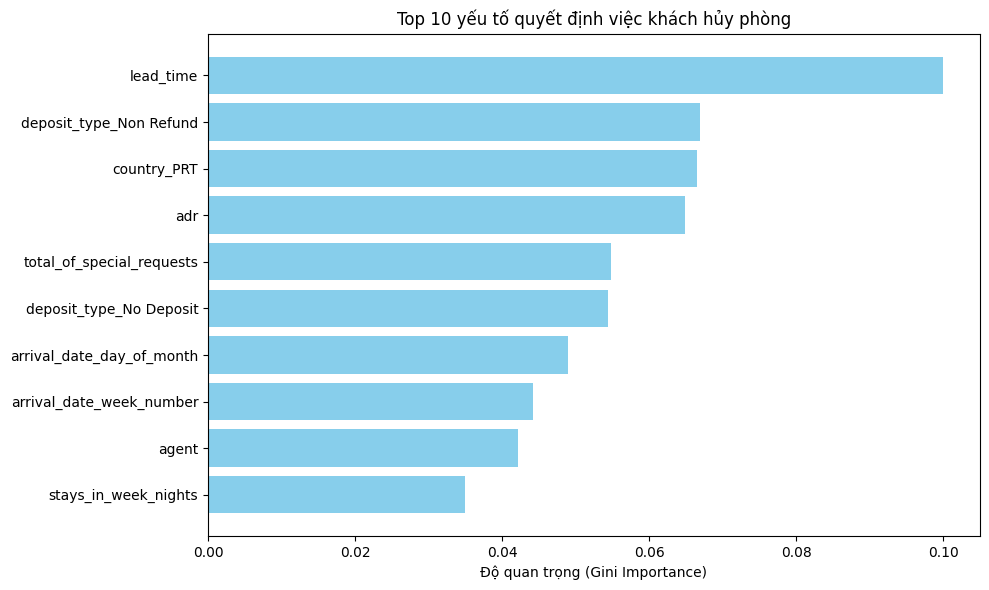

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Lấy độ quan trọng từ model đã train
importances = model.feature_importances_

# 2. Tự tạo lại danh sách tên cột giống như lúc train
# (Loại bỏ 'is_canceled' vì đó là cột mục tiêu)
feature_names = pd.get_dummies(df_cleaned.drop(columns=['is_canceled'])).columns

# 3. Sắp xếp và chọn Top 10
indices = np.argsort(importances)[-10:]

# 4. Vẽ biểu đồ
plt.figure(figsize=(10,6))
plt.title('Top 10 yếu tố quyết định việc khách hủy phòng')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Độ quan trọng (Gini Importance)')
plt.tight_layout()
plt.show()